=== MODEL ACCURACY: 90.00% ===

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.86      0.92         7
  Phishing (1)       0.75      1.00      0.86         3

      accuracy                           0.90        10
     macro avg       0.88      0.93      0.89        10
  weighted avg       0.93      0.90      0.90        10



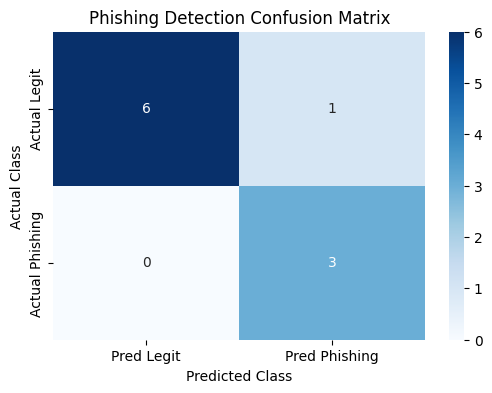


=== SAMPLE PREDICTIONS ===
🚨 PHISHING    | URGENT: Verify your bank password now to stop suspension
✅ LEGITIMATE  | Hey, do you have time to jump on a quick call today?
🚨 PHISHING    | Your package couldn't be delivered, click link to pay fee
✅ LEGITIMATE  | Please find attached the slides from the morning sync


In [ ]:
# Day 12: Phishing Email Detection with ML (Google Colab Ready)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# 1. Dataset Generation (50 samples: 25 Phishing, 25 Legitimate)
dataset = [
    # Phishing Emails (Label 1)
    ("Verify your account now or it will be suspended immediately", 1),
    ("Click here to claim your $1,000 gift card prize", 1),
    ("Urgent: Update your bank details to avoid account closure", 1),
    ("Your Apple ID has been locked due to suspicious activity", 1),
    ("Security Warning: Unauthorized login attempt detected on your account", 1),
    ("Congratulations! You have been selected for a free rewards card", 1),
    ("Immediate action required: Unpaid invoice attached", 1),
    ("Your Netflix subscription will be canceled within 24 hours", 1),
    ("Exclusive offer: Claim your reward points before they expire", 1),
    ("Important: Password expiry notice. Reset your credentials here", 1),
    ("Please verify your PayPal login details immediately", 1),
    ("Update your payment info to restore full account access", 1),
    ("Action required: Package delivery on hold due to wrong address", 1),
    ("Final warning: Tax refund waiting for immediate claim", 1),
    ("Your mailbox storage is full. Click to expand quota", 1),
    ("Encrypted message received. Log in to view details", 1),
    ("Urgent wire transfer request from executive management", 1),
    ("Your antivirus security license expired today. Renew now", 1),
    ("Click here to review your overdue traffic violation ticket", 1),
    ("Suspicious access attempt: Confirm your security PIN", 1),
    ("Account notification: Update credit card on file", 1),
    ("Your crypto wallet requires urgent re-verification", 1),
    ("Claim your hardship grant payment now", 1),
    ("Urgent payroll update: Direct deposit details required", 1),
    ("Your social media account will be permanently deactivated", 1),

    # Legitimate Emails (Label 0)
    ("Team standup scheduled for 3pm, agenda attached", 0),
    ("Your invoice for Q2 project work is ready for review", 0),
    ("Meeting notes and action items from yesterday's call", 0),
    ("Can we reschedule our 1-on-1 meeting to tomorrow morning?", 0),
    ("System maintenance planned for Friday night at midnight", 0),
    ("Please review the attached quarterly marketing plan", 0),
    ("Lunch and learn session in the main breakroom at noon", 0),
    ("Reminder: Please submit your weekly timesheets by EOD", 0),
    ("Happy work anniversary to the engineering team!", 0),
    ("Let's review the new product feature specs on Monday", 0),
    ("Are you available for a brief sync later today?", 0),
    ("Draft deck for the upcoming client presentation", 0),
    ("Approved: Your PTO request for next week has been logged", 0),
    ("Pull request submitted for backend API database migration", 0),
    ("Welcome to the department, glad to have you on board", 0),
    ("Thanks for updating the project documentation so quickly", 0),
    ("Updated Q3 roadmap and organizational goals attached", 0),
    ("Can anyone review the bug fix in the staging environment?", 0),
    ("Office closure announcement for the upcoming holiday", 0),
    ("IT alert: Scheduled database backup complete", 0),
    ("Here is the shareable link to the design prototypes", 0),
    ("Great job presenting during today's company demo", 0),
    ("Please review and sign the updated contract draft", 0),
    ("Don't forget to fill out the quarterly team feedback survey", 0),
    ("Details for the upcoming department offsite event", 0)
]

# Load into Pandas DataFrame
df = pd.DataFrame(dataset, columns=["text", "label"])

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.20,
    random_state=42
)

# 3. Build & Train Naive Bayes Pipeline
model = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

# 4. Evaluation Metrics
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"=== MODEL ACCURACY: {acc * 100:.2f}% ===\n")
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=["Legitimate (0)", "Phishing (1)"]))

# 5. Confusion Matrix Visualization (Renders inline in Colab)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Legit", "Pred Phishing"],
    yticklabels=["Actual Legit", "Actual Phishing"]
)
plt.title("Phishing Detection Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# 6. Sample Prediction Test
print("\n=== SAMPLE PREDICTIONS ===")
sample_emails = [
    "URGENT: Verify your bank password now to stop suspension",
    "Hey, do you have time to jump on a quick call today?",
    "Your package couldn't be delivered, click link to pay fee",
    "Please find attached the slides from the morning sync"
]

for text in sample_emails:
    prediction = model.predict([text])[0]
    status = "🚨 PHISHING" if prediction == 1 else "✅ LEGITIMATE"
    print(f"{status:<13} | {text}")